# Non-Linear Regression


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [2]:
#load dataset
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\World_Population_analysis\data\population.csv")
df.head()

,Country Name,Country Code,Year,Value
0,Aruba,ABW,1960,54922.0
1,Aruba,ABW,1961,55578.0
2,Aruba,ABW,1962,56320.0
3,Aruba,ABW,1963,57002.0
4,Aruba,ABW,1964,57619.0


In [3]:
#Filter for world population only
df_world=df[df['Country Name']=='World']
df_world.head()

,Country Name,Country Code,Year,Value
16482,World,WLD,1960,3.021529e+09
16483,World,WLD,1961,3.062769e+09
16484,World,WLD,1962,3.117373e+09
16485,World,WLD,1963,3.184063e+09
16486,World,WLD,1964,3.251253e+09


In [4]:
#Prepare x and y
x_data=df_world['Year'].values
y_data=df_world['Value'].values

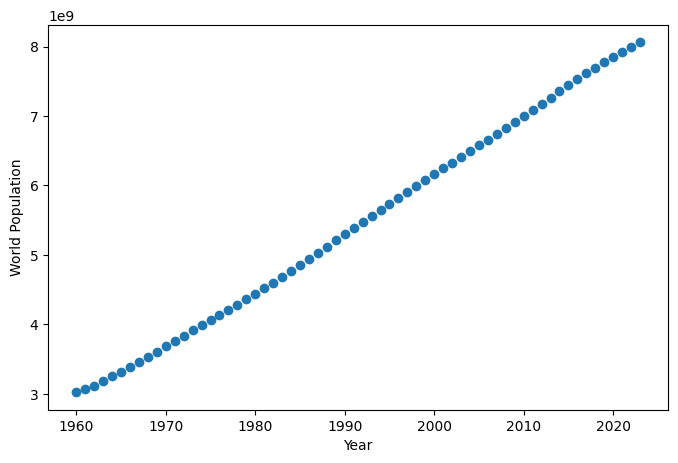

In [5]:
#plot
plt.figure(figsize=(8,5))
plt.scatter(x_data,y_data)
plt.xlabel("Year")
plt.ylabel("World Population")
plt.show()

In [ ]:
#since world population is sigmoid but the above plot shows only a portion of a sigmoid plot. We will use sigmoid function
def sigmoid(x,beta_1,beta_2):
    return 1/(1+np.exp(-beta_1*(x-beta_2)))

In [7]:
#normalize the data
x_norm=x_data/max(x_data)
y_norm=y_data/max(y_data)

In [8]:
#fit the model 
popt,pcov=curve_fit(sigmoid,x_norm,y_norm)
print("Optimized parameters:",popt)

Optimized parameters: [100.84750121   0.97595748]


popt[0]=growth speed
popt[1]=midpoint year(normalized)

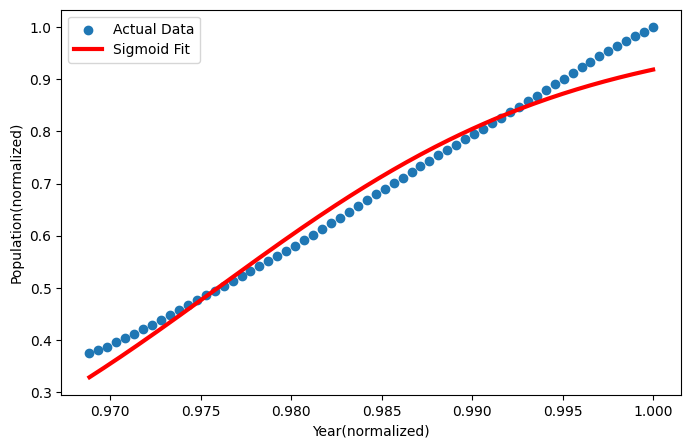

In [9]:
#plot the fitted curve
x_line=np.linspace(min(x_norm),max(x_norm),200)
y_line=sigmoid(x_line,*popt)
plt.figure(figsize=(8,5))
plt.scatter(x_norm,y_norm,label='Actual Data')
plt.plot(x_line,y_line,color="red",linewidth=3,label="Sigmoid Fit")
plt.xlabel("Year(normalized)")
plt.ylabel("Population(normalized)")
plt.legend()
plt.show()

In [10]:
#Train-Test Split (Validation)
msk=np.random.rand(len(x_norm))<0.8
train_x=x_norm[msk]
test_x=x_norm[~msk]
train_y=y_norm[msk]
test_y=y_norm[~msk]

In [11]:
#train on training data 
popt, _ =curve_fit(sigmoid,train_x,train_y)

In [12]:
#predict on test data
y_hat=sigmoid(test_x,*popt)

In [13]:
#Model Evaluation
print("MAE : ",np.mean(np.abs(y_hat-test_y)))
print("MSE : ",np.mean((y_hat-test_y)**2))
print("R2 Score : ",r2_score(test_y,y_hat))

MAE :  0.028387755467596976
MSE :  0.0013190346312390861
R2 Score :  0.956803385805451
